### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: dividend per share (dps), p/b ratio, free cash flow yield, monthly momentum, mean reversal signal
10. Universe size over time
11. Portfolio breadth over time
12. Long composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/value_full_price_available_universe_modular"
STRATEGY_NAME = "Value Strategy"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (310, 4)
asset_returns: (114490, 11)
weights_at_E: (114490, 26)
signals_at_T: (573135, 22)
portfolio_membership_at_T: (114490, 25)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0 or monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
monthly = (
    asset_returns
    .groupby(["signal_date", "execution_date", "next_execution_date"], as_index=False)["weighted_return"]
    .sum()
    .rename(columns={"weighted_return": "portfolio_return_rebuilt"})
)

monthly.head()

,signal_date,execution_date,next_execution_date,portfolio_return_rebuilt
0,2000-02-29,2000-03-01,2000-04-03,0.108851
1,2000-03-31,2000-04-03,2000-05-01,0.016176
2,2000-04-28,2000-05-01,2000-06-01,0.016772
3,2000-05-31,2000-06-01,2000-07-03,-0.010343
4,2000-06-30,2000-07-03,2000-08-01,0.025464


In [8]:
check = portfolio_returns.merge(
    monthly,
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["portfolio_return_rebuilt"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 2.2815083156046967e-14
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_only_portfolio": performance_summary(monthly["portfolio_return_rebuilt"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_only_portfolio,0.013254,0.06184,0.742442,0.625806,-0.572347


### 5. Cumulative performance plot: Long / Net

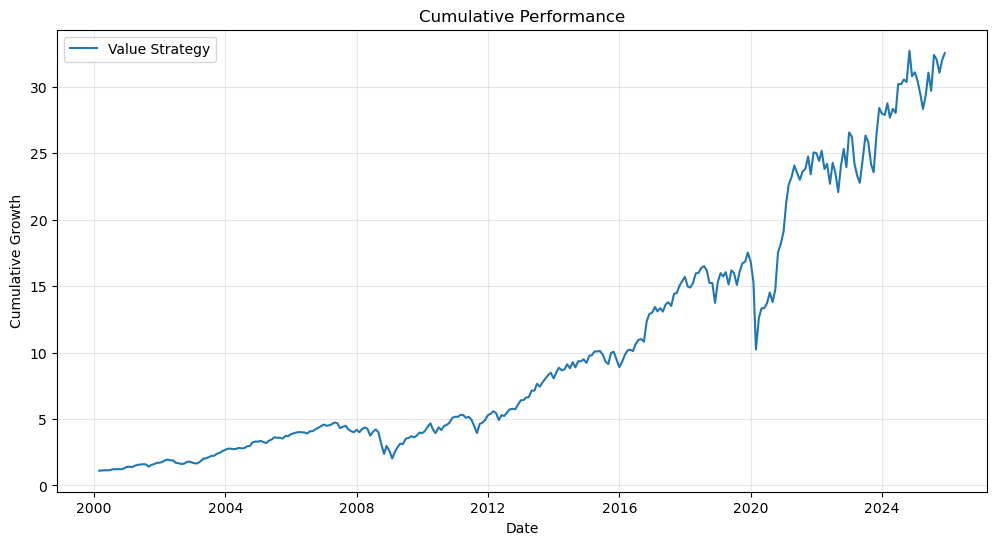

In [10]:
plot_df = monthly.sort_values("signal_date").copy()
plot_df["cum_portfolio"] = (1 + plot_df["portfolio_return_rebuilt"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_portfolio"], label="Value Strategy")
plt.title("Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

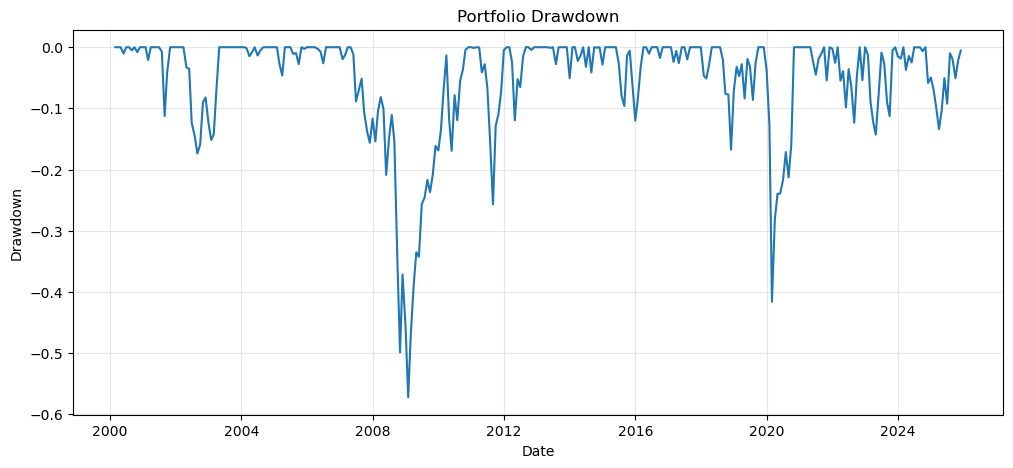

In [11]:
drawdown_df = plot_df[["signal_date", "portfolio_return_rebuilt"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["portfolio_return_rebuilt"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

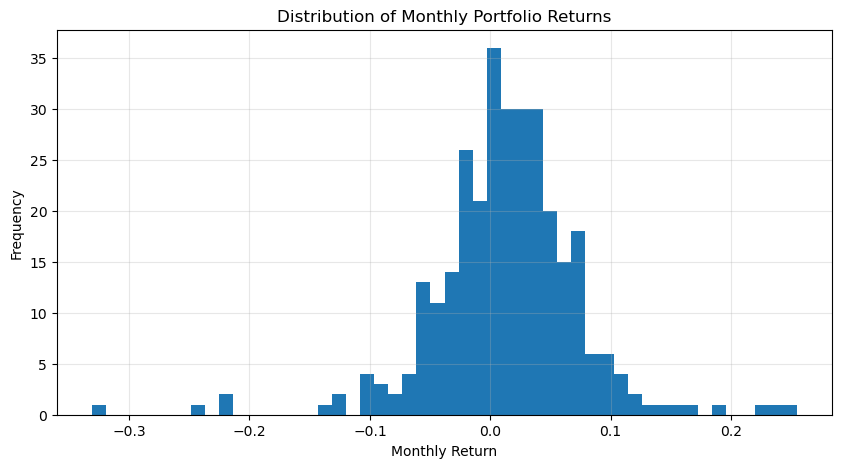

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(monthly["portfolio_return_rebuilt"], bins=50)
plt.title("Distribution of Monthly Portfolio Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
monthly["portfolio_return_rebuilt"].describe()

count    310.000000
mean       0.013254
std        0.061840
min       -0.330601
25%       -0.018998
50%        0.014551
75%        0.045576
max        0.254591
Name: portfolio_return_rebuilt, dtype: float64

In [14]:
signal_cols_to_check = [
    c for c in ["dps_proxy", "pb", "fcf_yield", "mom_1m", "reversal_signal"]
    if c in weights_at_E.columns
]
signal_cols_to_check

['dps_proxy', 'pb', 'fcf_yield', 'mom_1m', 'reversal_signal']

In [15]:
for col in signal_cols_to_check:
    print(f"\n=== {col} ===")
    display(weights_at_E[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


=== dps_proxy ===


count    1.144900e+05
mean     3.412647e+11
std      3.069173e+13
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
50%      5.740432e-01
95%      4.601473e+00
99%      1.387681e+02
max      3.631914e+15
Name: dps_proxy, dtype: float64


=== pb ===


count    114490.000000
mean          1.463647
std           4.891144
min           0.000001
1%            0.009863
5%            0.411196
50%           1.205530
95%           2.987715
99%           5.298454
max        1398.189443
Name: pb, dtype: float64


=== fcf_yield ===


count    114490.000000
mean         16.764612
std        1980.474756
min       -3762.361801
1%           -0.219932
5%            0.018667
50%           0.109642
95%           0.555039
99%           7.630144
max      306335.708244
Name: fcf_yield, dtype: float64


=== mom_1m ===


count    114490.000000
mean         -0.038052
std           0.095780
min          -4.406742
1%           -0.335790
5%           -0.198364
50%          -0.027968
95%           0.088893
99%           0.170980
max           1.660377
Name: mom_1m, dtype: float64


=== reversal_signal ===


count    114490.000000
mean          0.038052
std           0.095780
min          -1.660377
1%           -0.170980
5%           -0.088893
50%           0.027968
95%           0.198364
99%           0.335790
max           4.406742
Name: reversal_signal, dtype: float64

### 9. Signal diagnostics: dividend per share (dps), p/b ratio, free cash flow yield, monthly momentum, mean reversal signal

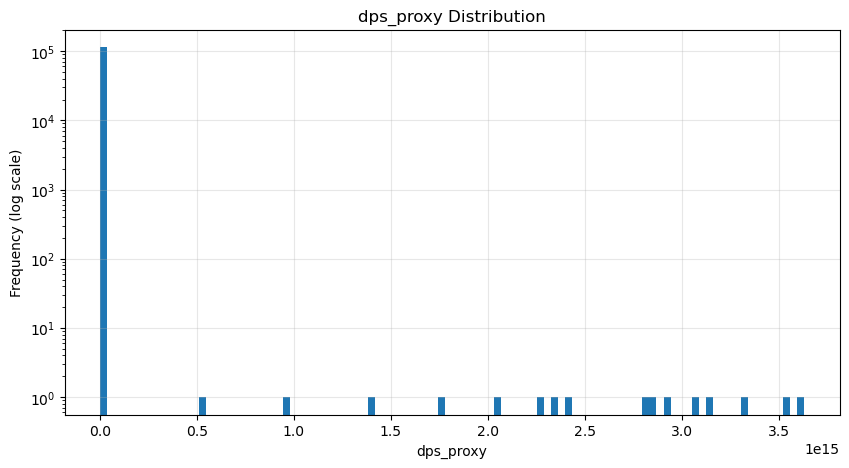

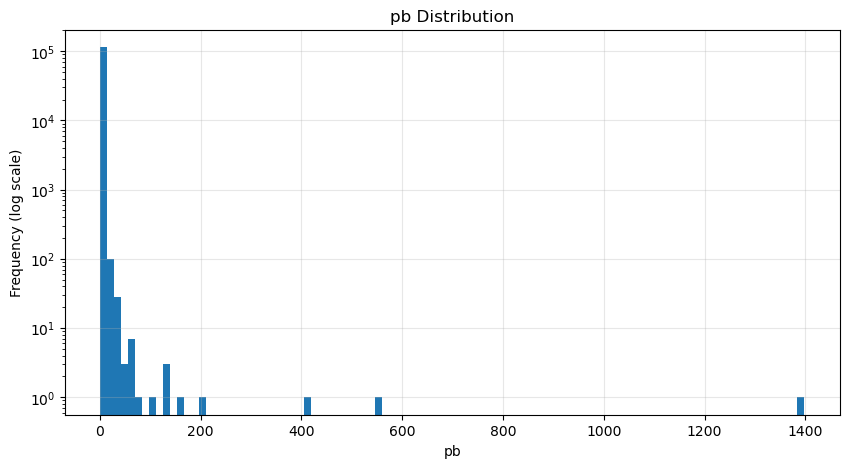

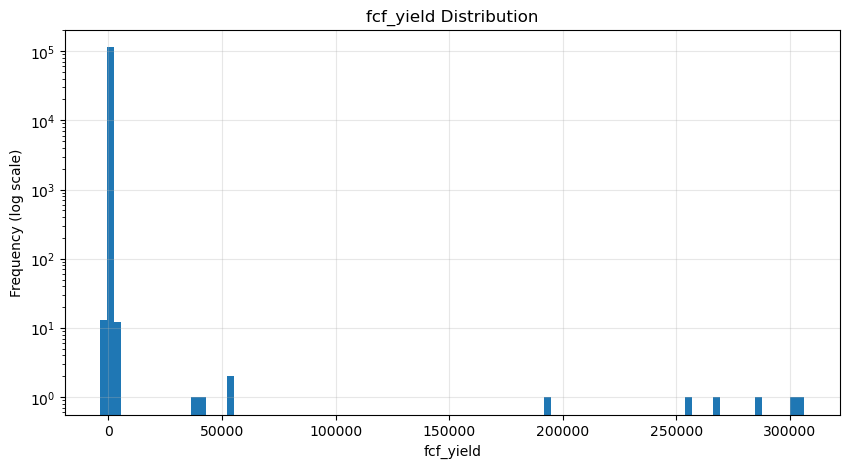

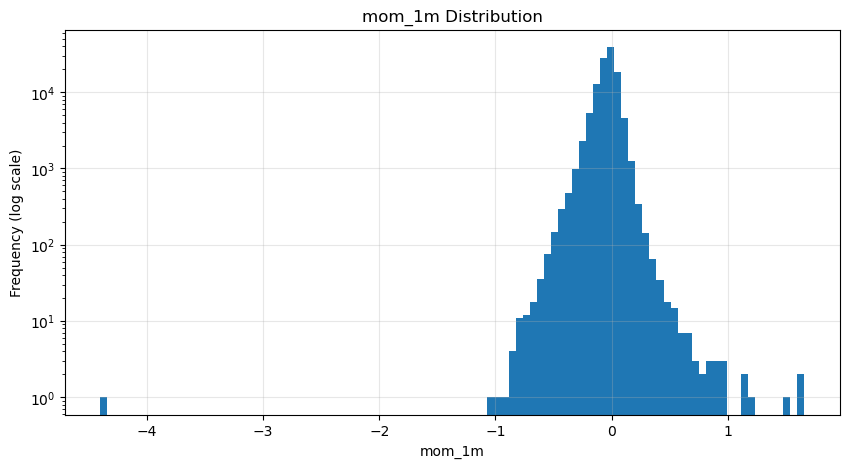

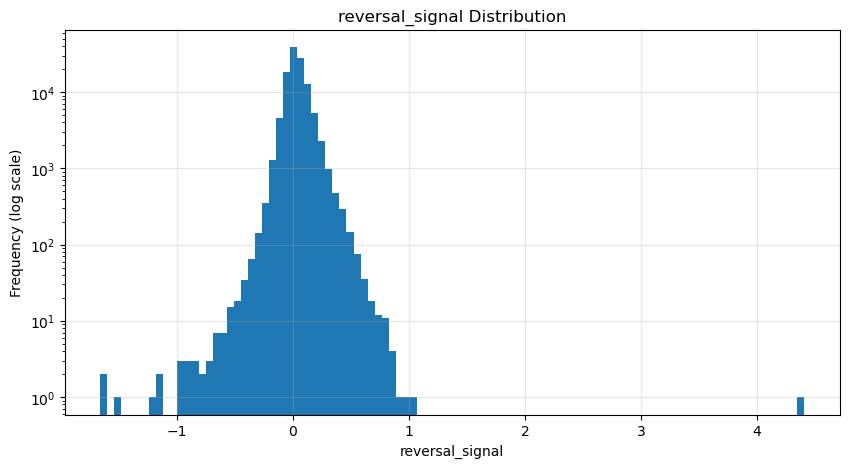

In [16]:
for col in signal_cols_to_check:
    plt.figure(figsize=(10, 5))
    plt.hist(weights_at_E[col].dropna(), bins=100)
    plt.yscale("log")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, alpha=0.3)
    plt.show()

### 10. Universe size over time

In [17]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2000-02-29,742
1,2000-03-31,770
2,2000-04-28,774
3,2000-05-31,755
4,2000-06-30,764


In [18]:
universe_size["n_universe"].describe()

count     310.000000
mean     1848.822581
std       681.697185
min       742.000000
25%      1326.250000
50%      1685.000000
75%      2338.500000
max      3042.000000
Name: n_universe, dtype: float64

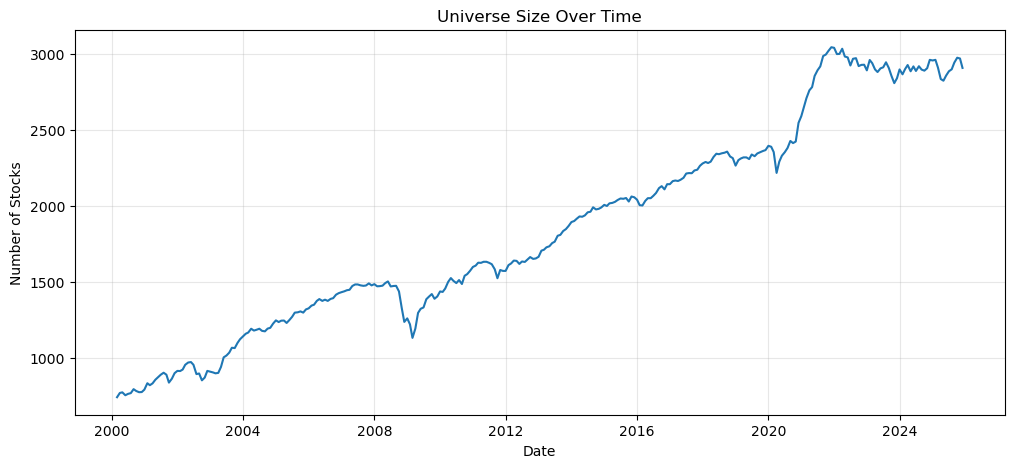

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [20]:
breadth = (
    asset_returns.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_long")
)

breadth.head()

,signal_date,n_long
0,2000-02-29,148
1,2000-03-31,154
2,2000-04-28,154
3,2000-05-31,151
4,2000-06-30,152


In [21]:
breadth["n_long"].describe()

count    310.000000
mean     369.322581
std      136.330834
min      148.000000
25%      265.000000
50%      337.000000
75%      467.000000
max      608.000000
Name: n_long, dtype: float64

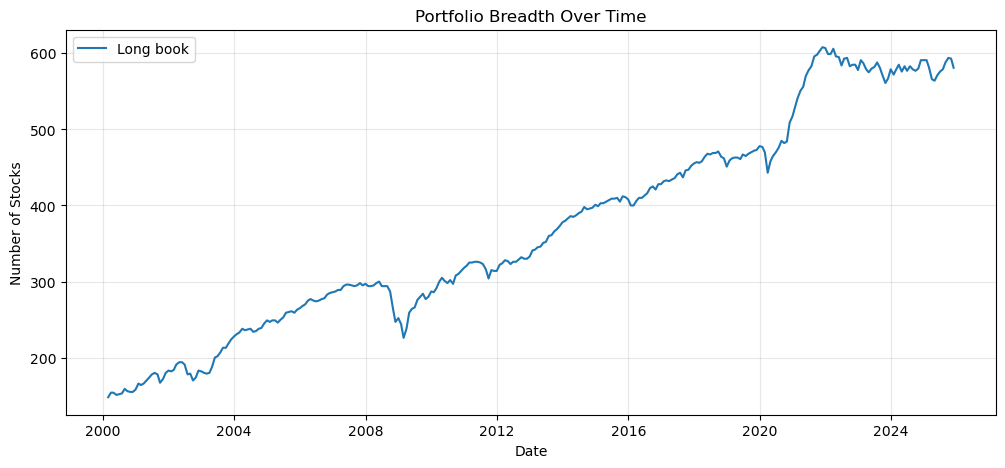

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(breadth["signal_date"], breadth["n_long"], label="Long book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long composition

In [23]:
factor_cols = [
    c for c in ["market_cap", "pb", "dps_proxy", "fcf_yield", "mom_1m", "reversal_signal"]
    if c in weights_at_E.columns
]

factor_summary = weights_at_E[factor_cols].mean().to_frame("long_book_mean")
factor_summary

,long_book_mean
market_cap,1.075907e+10
pb,1.463647e+00
dps_proxy,3.412647e+11
fcf_yield,1.676461e+01
mom_1m,-3.805247e-02
reversal_signal,3.805247e-02


In [24]:
factor_check = (
    weights_at_E
    .groupby("signal_date")[factor_cols]
    .mean()
    .reset_index()
)

factor_check.head()

,signal_date,market_cap,pb,dps_proxy,fcf_yield,mom_1m,reversal_signal
0,2000-02-29,6.432294e+09,1.462461,1.917017,0.144521,-0.105496,0.105496
1,2000-03-31,4.445815e+09,1.577941,1.903301,0.123698,0.007328,-0.007328
2,2000-04-28,5.585837e+09,1.695805,1.997926,0.141965,-0.044744,0.044744
3,2000-05-31,3.864976e+09,1.399006,1.756531,0.139447,-0.040029,0.040029
4,2000-06-30,3.912653e+09,1.402501,1.855768,0.149789,-0.087908,0.087908


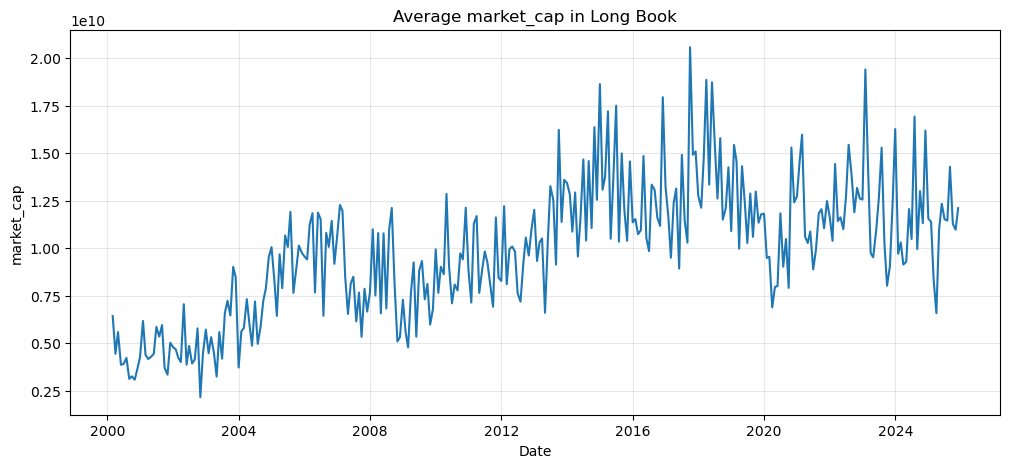

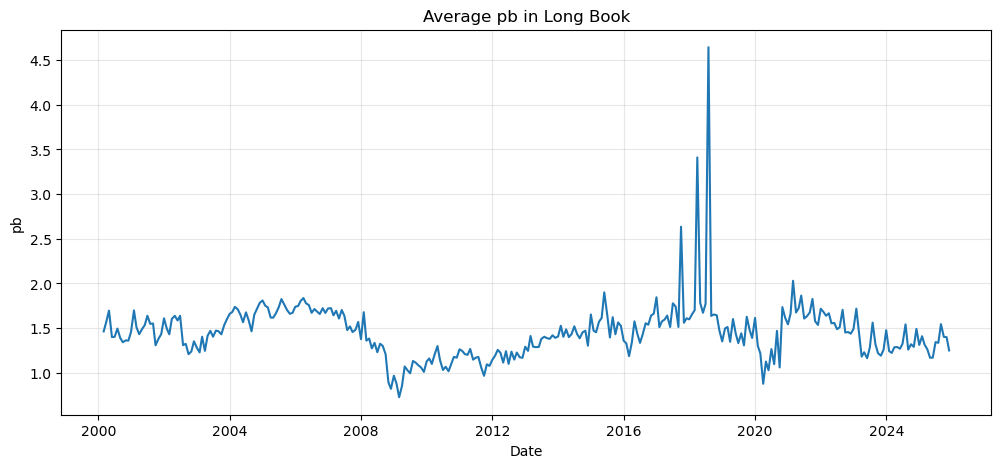

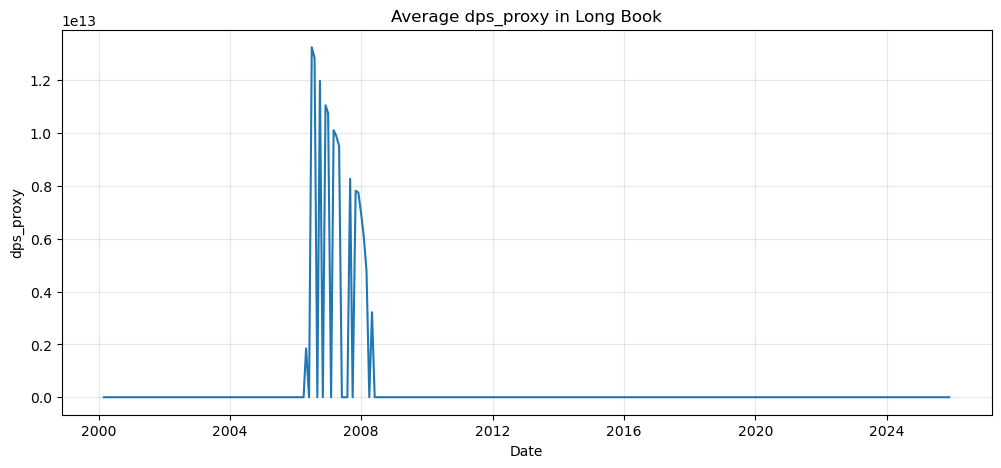

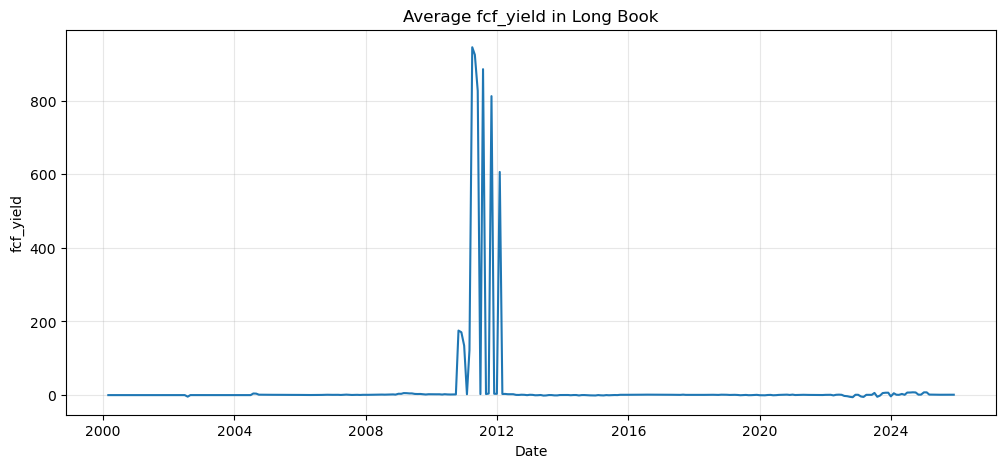

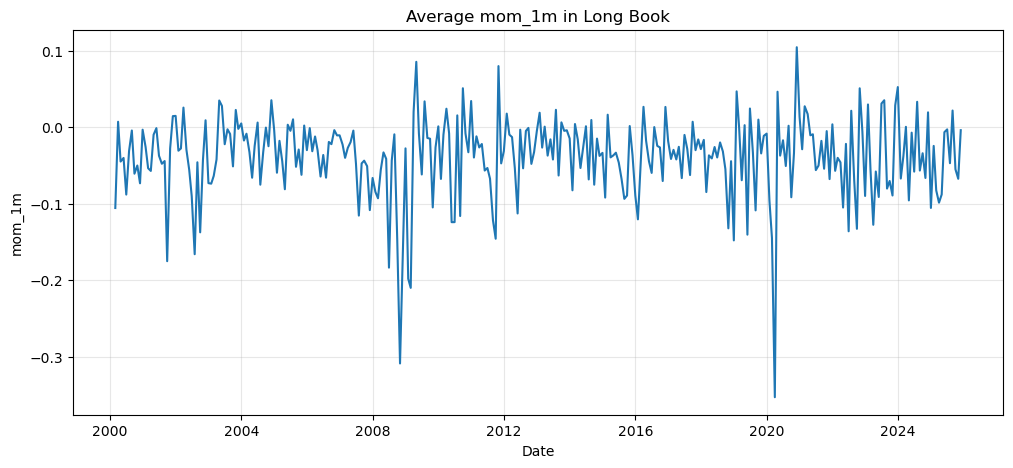

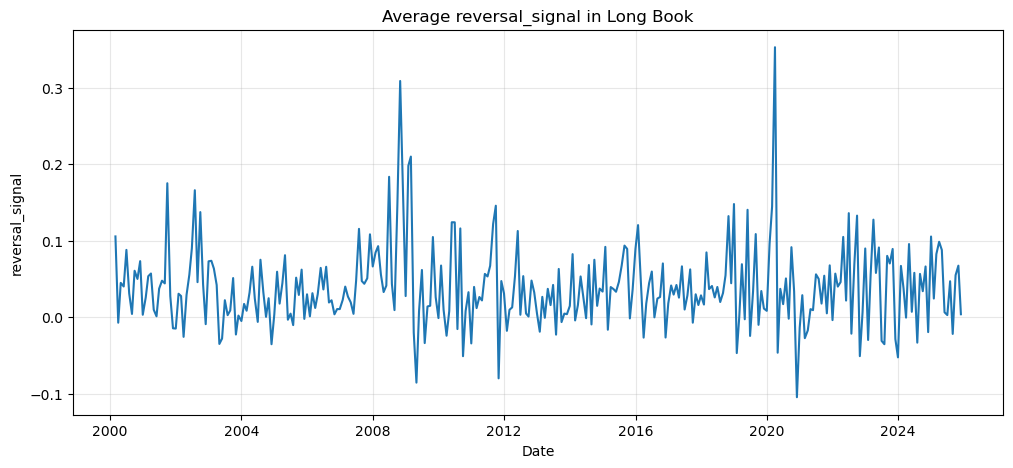

In [25]:
for col in factor_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(factor_check["signal_date"], factor_check[col])
    plt.title(f"Average {col} in Long Book")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

### 13. Benchmark comparison vs S&P 500

In [26]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])
sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [27]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [28]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(219, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2000-02-29,2000-03-01,2000-04-03,0.108851,-0.020108
1,2000-03-31,2000-04-03,2000-05-01,0.016176,0.096720
2,2000-05-31,2000-06-01,2000-07-03,-0.010343,-0.021915
3,2000-06-30,2000-07-03,2000-08-01,0.025464,0.023934
4,2000-07-31,2000-08-01,2000-09-01,0.051329,-0.016341


In [29]:
merged["cum_value"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_value", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_value,cum_sp
0,2000-02-29,0.108851,-0.020108,1.108851,0.979892
1,2000-03-31,0.016176,0.096720,1.126788,1.074667
2,2000-05-31,-0.010343,-0.021915,1.115133,1.051116
3,2000-06-30,0.025464,0.023934,1.143528,1.076272
4,2000-07-31,0.051329,-0.016341,1.202225,1.058685


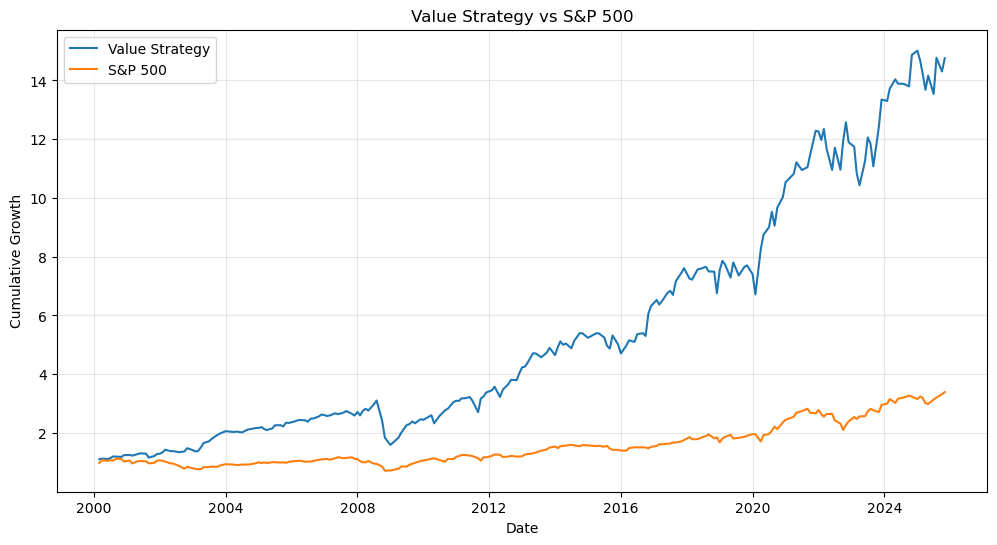

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_value"], label="Value Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("Value Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
print("Value Strategy Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

Value Strategy Sharpe: 0.857777018976411
S&P 500 Sharpe: 0.5126480875005088


In [32]:
benchmark_summary = pd.DataFrame({
    "Value Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
Value Strategy,0.013969,0.056415,0.857777,0.611872,-0.486970
S&P 500,0.006593,0.044552,0.512648,0.607306,-0.391858


### 14. Turnover

In [33]:
membership_sets = (
    weights_at_E.groupby("signal_date")["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values("signal_date")
    .reset_index(drop=True)
)

turnover_records = []
for i in range(1, len(membership_sets)):
    prev_set = membership_sets.loc[i - 1, "ticker_set"]
    curr_set = membership_sets.loc[i, "ticker_set"]

    entered = len(curr_set - prev_set)
    exited = len(prev_set - curr_set)
    union_n = len(curr_set | prev_set)
    prev_n = len(prev_set)

    turnover_records.append({
        "signal_date": membership_sets.loc[i, "signal_date"],
        "entered": entered,
        "exited": exited,
        "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
        "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
    })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2000-03-31,67,61,0.864865,0.404651
1,2000-04-28,61,61,0.792208,0.432558
2,2000-05-31,49,52,0.655844,0.502463
3,2000-06-30,56,55,0.735099,0.463768
4,2000-07-31,58,57,0.756579,0.452381


In [34]:
turnover_df.describe()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
count,309,309.000000,309.000000,309.000000,309.000000
mean,2013-01-28 21:49:30.873786368,133.365696,131.964401,0.734636,0.465216
min,2000-03-31 00:00:00,43.000000,46.000000,0.421416,0.352403
25%,2006-08-31 00:00:00,96.000000,95.000000,0.667797,0.432558
50%,2013-01-31 00:00:00,131.000000,130.000000,0.735915,0.461972
75%,2019-06-28 00:00:00,170.000000,169.000000,0.792208,0.498118
max,2025-11-28 00:00:00,232.000000,222.000000,0.952862,0.650930
std,NaN,43.906101,43.701341,0.089943,0.047754


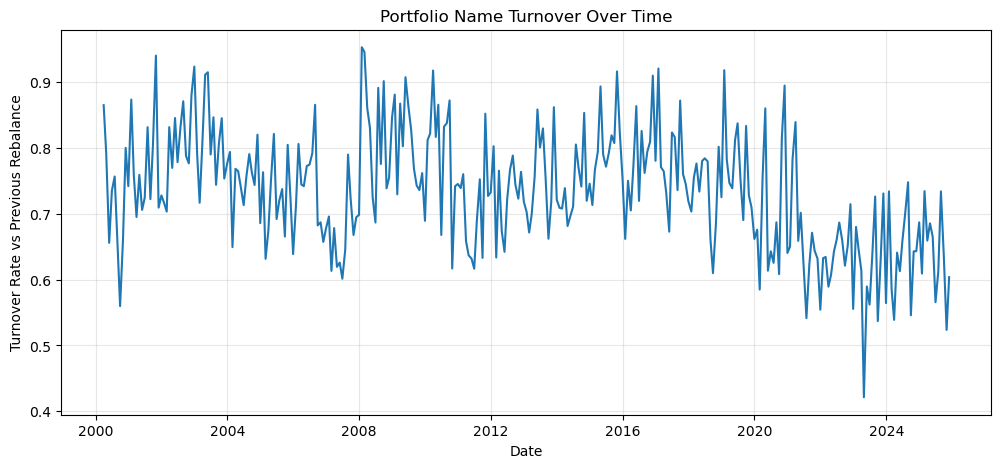

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_df["signal_date"], turnover_df["turnover_rate_vs_prev"])
plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [36]:
print("=== MODEL SUMMARY ===")
print(f"Annualized Sharpe: {annualized_sharpe(monthly['portfolio_return_rebuilt']):.4f}")
print(f"Max drawdown: {max_drawdown(monthly['portfolio_return_rebuilt']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth['n_long'].mean():.2f}")
print(f"Average turnover: {turnover_df['turnover_rate_vs_prev'].mean():.4f}")

=== MODEL SUMMARY ===
Annualized Sharpe: 0.7424
Max drawdown: -0.5723
Average universe size: 1848.82
Average long breadth: 369.32
Average turnover: 0.7346
